# EJEMPLO COMPLETO DE PREPROCESAMIENTO DE LOS DATOS

In [93]:
# Importación de las bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

## Cargar csv

In [94]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/datasetU2L2.csv'
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
df

,ID_cliente,Altura_cm,Peso_kg,Gasto_mensual,Años_experiencia,Compras_mes,Región,Nivel_estudios
0,1,175.0,60.5,1162.0,5.6,3.0,Norte,Básica
1,2,168.6,68.6,913.0,1.6,4.0,Sur,Grado
2,3,176.5,76.1,718.0,2.3,2.0,Este,Máster
3,4,185.2,80.4,1261.0,6.5,2.0,Oeste,Doctorado
4,5,167.7,55.6,973.0,5.3,NaN,Norte,Básica
...,...,...,...,...,...,...,...,...
242,94,166.7,61.9,1134.0,5.4,NaN,Sur,Grado
243,110,169.3,67.4,943.0,4.4,2.0,Sur,Grado
244,105,168.4,64.3,1255.0,4.1,2.0,Norte,Básica
245,173,169.2,51.6,1119.0,7.1,3.0,Norte,Básica


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_cliente        247 non-null    int64  
 1   Altura_cm         247 non-null    float64
 2   Peso_kg           247 non-null    float64
 3   Gasto_mensual     247 non-null    float64
 4   Años_experiencia  247 non-null    float64
 5   Compras_mes       234 non-null    float64
 6   Región            247 non-null    object 
 7   Nivel_estudios    247 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


## Selección de características

In [97]:
# Eliminamos la columna 'ID_cliente' porque es un identificador único y no aporta información útil al modelo
df = df.drop(columns=["ID_cliente"])

## Nulos

In [98]:
# Mostramos cuántos valores nulos hay en cada columna
print(df.isnull().sum())

Altura_cm            0
Peso_kg              0
Gasto_mensual        0
Años_experiencia     0
Compras_mes         13
Región               0
Nivel_estudios       0
dtype: int64


In [99]:
# Rellenamos los nulos de 'Compras_mes' con la mediana, para no afectar con valores extremos
df["Compras_mes"] = df["Compras_mes"].fillna(df["Compras_mes"].median())

In [100]:
print(df.isnull().sum())

Altura_cm           0
Peso_kg             0
Gasto_mensual       0
Años_experiencia    0
Compras_mes         0
Región              0
Nivel_estudios      0
dtype: int64


## Únicos

In [101]:
# Mostramos los valores únicos de 'Región'
print("Regiones únicas:", df["Región"].unique())

# Mostramos los valores únicos de 'Nivel_estudios'
print("Niveles de estudio únicos:", df["Nivel_estudios"].unique())

Regiones únicas: ['Norte' 'Sur' 'Este' 'Oeste']
Niveles de estudio únicos: ['Básica' 'Grado' 'Máster' 'Doctorado']


## Duplicados

In [102]:
# Comprobamos cuántas filas están duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 7


In [103]:
# Eliminamos las filas duplicadas manteniendo solo la primera aparición
df = df.drop_duplicates()

In [104]:
# Comprobamos cuántas filas están duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


## Distribuciones

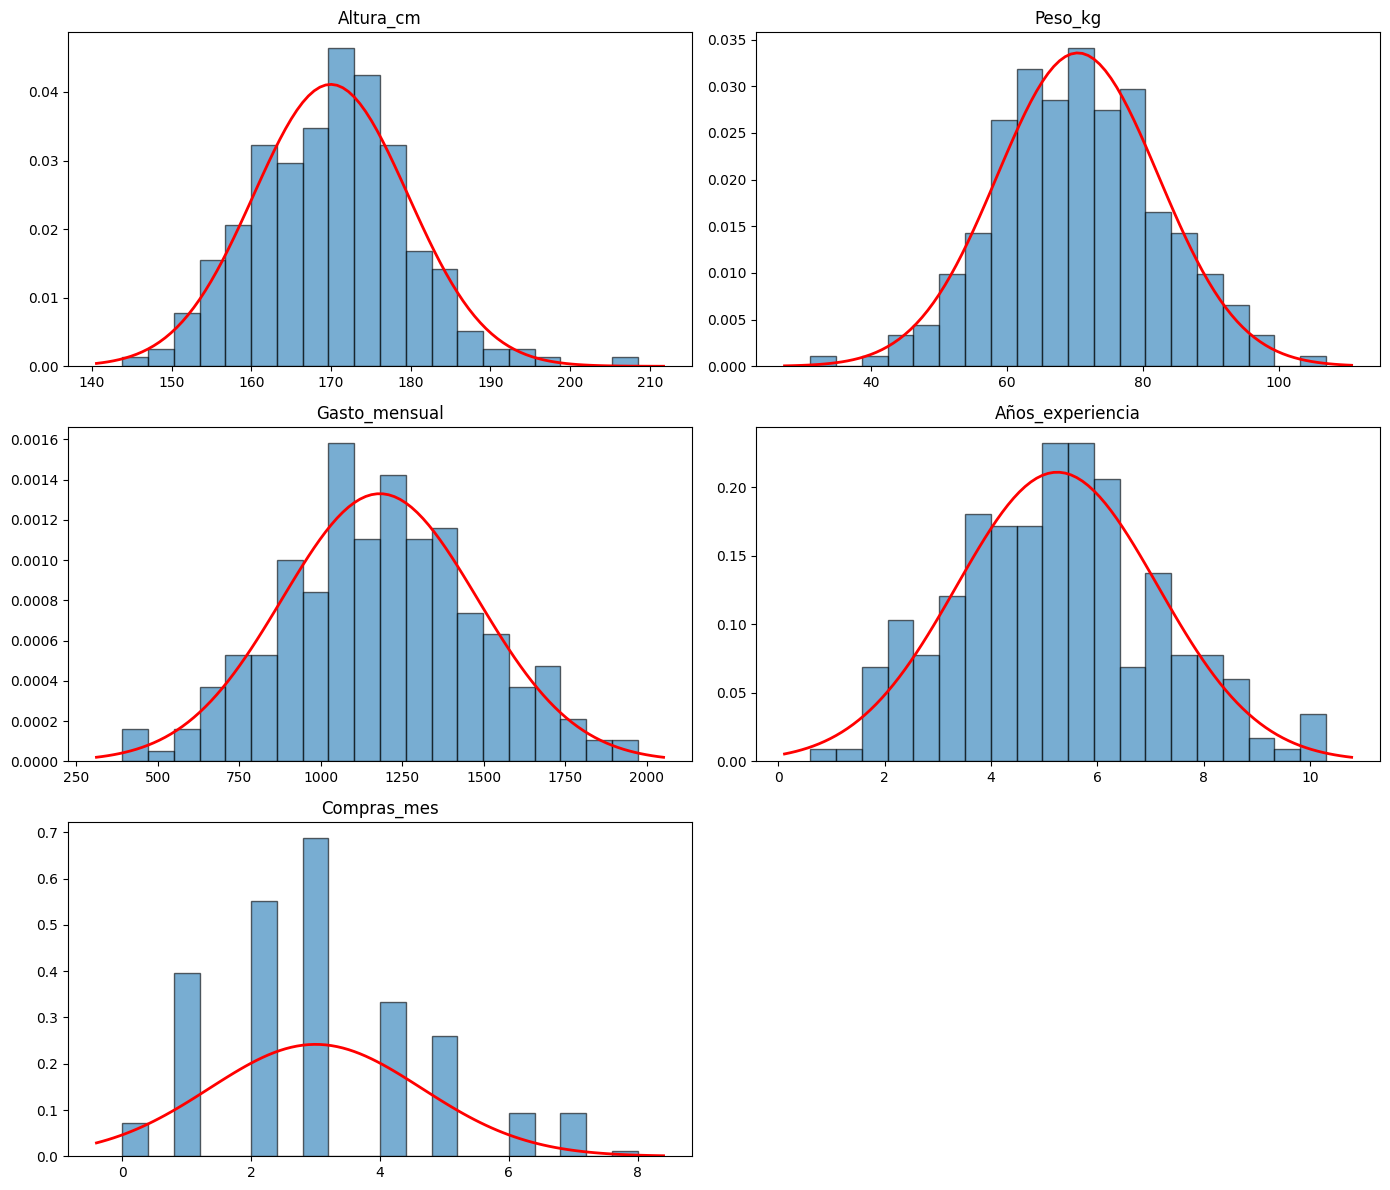

In [105]:
import matplotlib.pyplot as plt
import scipy.stats as stats

columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=20, density=True, alpha=0.6, edgecolor='black')
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, data.mean(), data.std())
    ax.plot(x, p, 'r', linewidth=2)
    ax.set_title(col)

# Ocultamos la última gráfica vacía si hay menos de 6 columnas
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusiones sobre las distribuciones

Al observar que todas las variables numéricas tienen una distribución aproximadamente gaussiana, podemos sacar varias conclusiones:

- Es adecuado aplicar `StandardScaler`, ya que funciona bien cuando los datos están centrados en la media y con varianza constante.
- No es necesario transformar las variables (con log, raíz cuadrada o Box-Cox), porque no hay sesgo significativo.
- El análisis de componentes principales (PCA) se verá beneficiado, ya que parte de la suposición de distribuciones normales.
- Los modelos lineales, como la regresión lineal, ridge o incluso LDA si usáramos clasificación, funcionarán de forma más eficiente con este tipo de datos.


## Correlaciones con la variable objectivo

In [106]:
# Mostramos la correlación entre cada variable numérica y la variable objetivo
correlaciones = df.select_dtypes(include=["float64", "int64"]).corr()["Compras_mes"].drop("Compras_mes")
print(correlaciones)


Altura_cm           0.073396
Peso_kg            -0.023791
Gasto_mensual       0.006828
Años_experiencia   -0.054438
Name: Compras_mes, dtype: float64


El coeficiente de correlación de Pearson mide la relación lineal entre dos variables numéricas. Su valor siempre está entre -1 y 1:

- 1 indica una correlación lineal positiva perfecta (si una variable sube, la otra también)

- -1 indica una correlación lineal negativa perfecta (si una sube, la otra baja)

- 0 indica que no hay relación lineal

- Altura_cm: 0.07 — hay una relación muy débil y positiva
- Peso_kg: -0.02 — prácticamente nula y ligeramente negativa
- Gasto_mensual: 0.006 — inexistente
- Años_experiencia: -0.05 — muy débil y negativa

Si todas las correlaciones con el target (Compras_mes) son débiles (cerca de 0), significa que:

- Ninguna variable por sí sola explica mucho de lo que ocurre con Compras_mes
- Puede haber combinaciones de variables que sí aporten información útil (interacciones)
- Es posible que la relación no sea lineal, sino más compleja
- O que falten variables importantes en el dataset

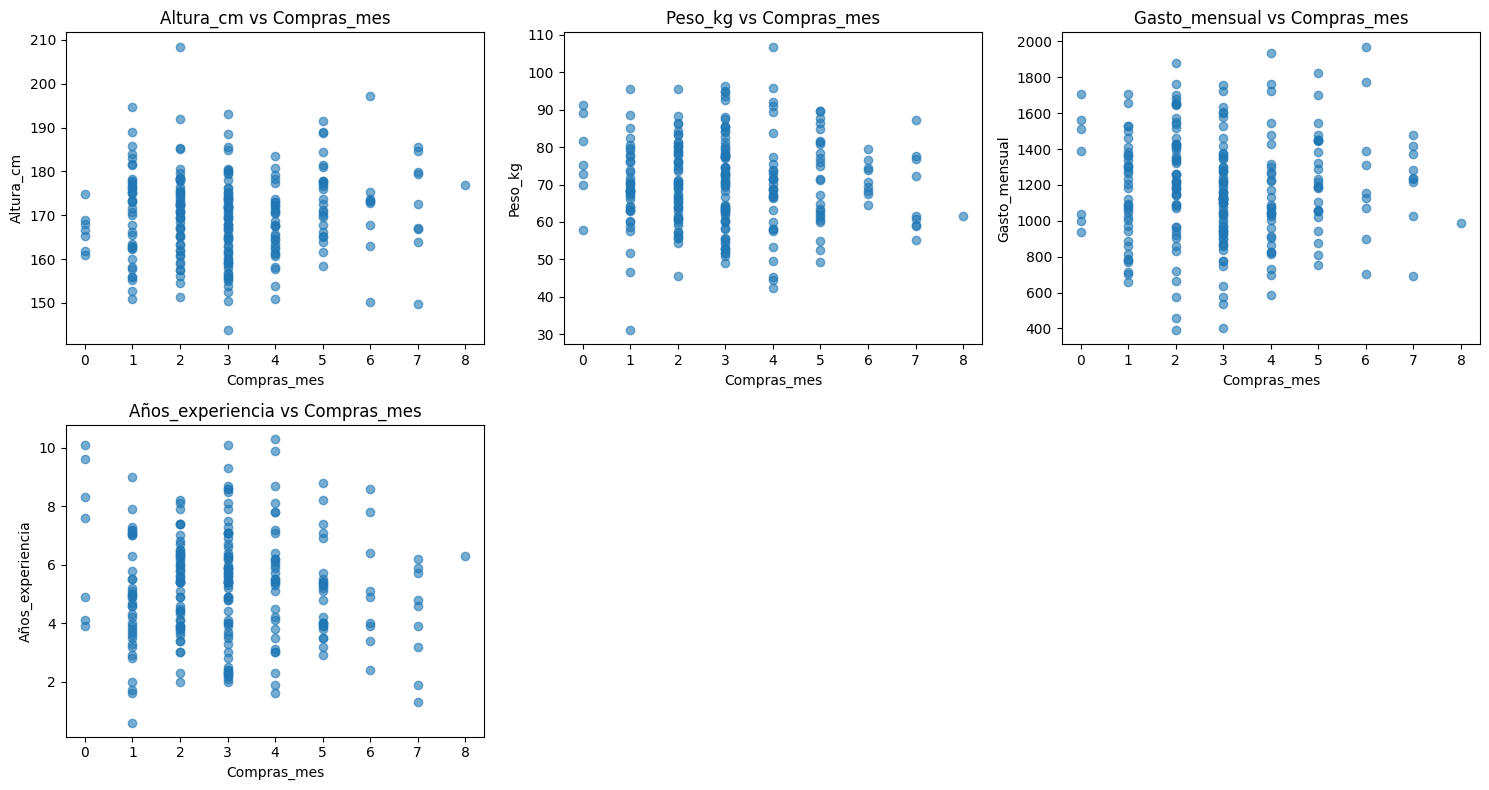

In [107]:
import matplotlib.pyplot as plt

features = df.select_dtypes(include=["float64", "int64"]).columns.drop("Compras_mes")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df["Compras_mes"], df[col], alpha=0.6)
    axes[i].set_title(f"{col} vs Compras_mes")
    axes[i].set_xlabel("Compras_mes")
    axes[i].set_ylabel(col)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Equilibrio

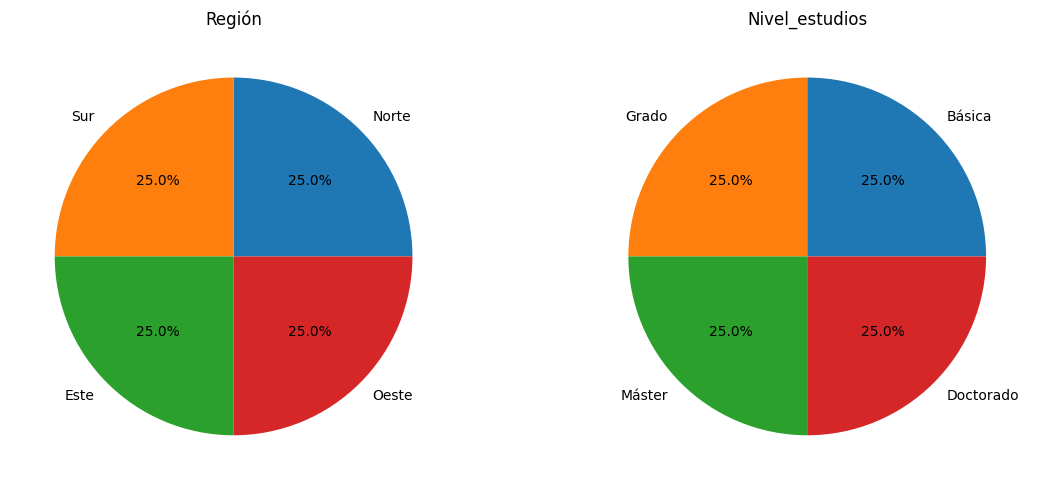

In [108]:
import matplotlib.pyplot as plt

cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(1, len(cat_cols), figsize=(12, 5))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

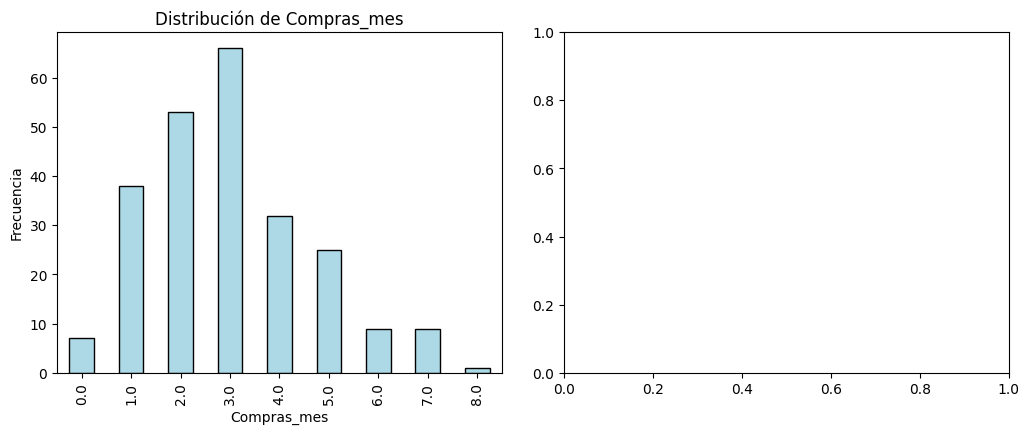

In [109]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(exclude="object").columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    valores_unicos = df[col].nunique()
    if valores_unicos <= 20:
        df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i], color="lightblue", edgecolor="black")
        axes[i].set_title(f"Distribución de {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()


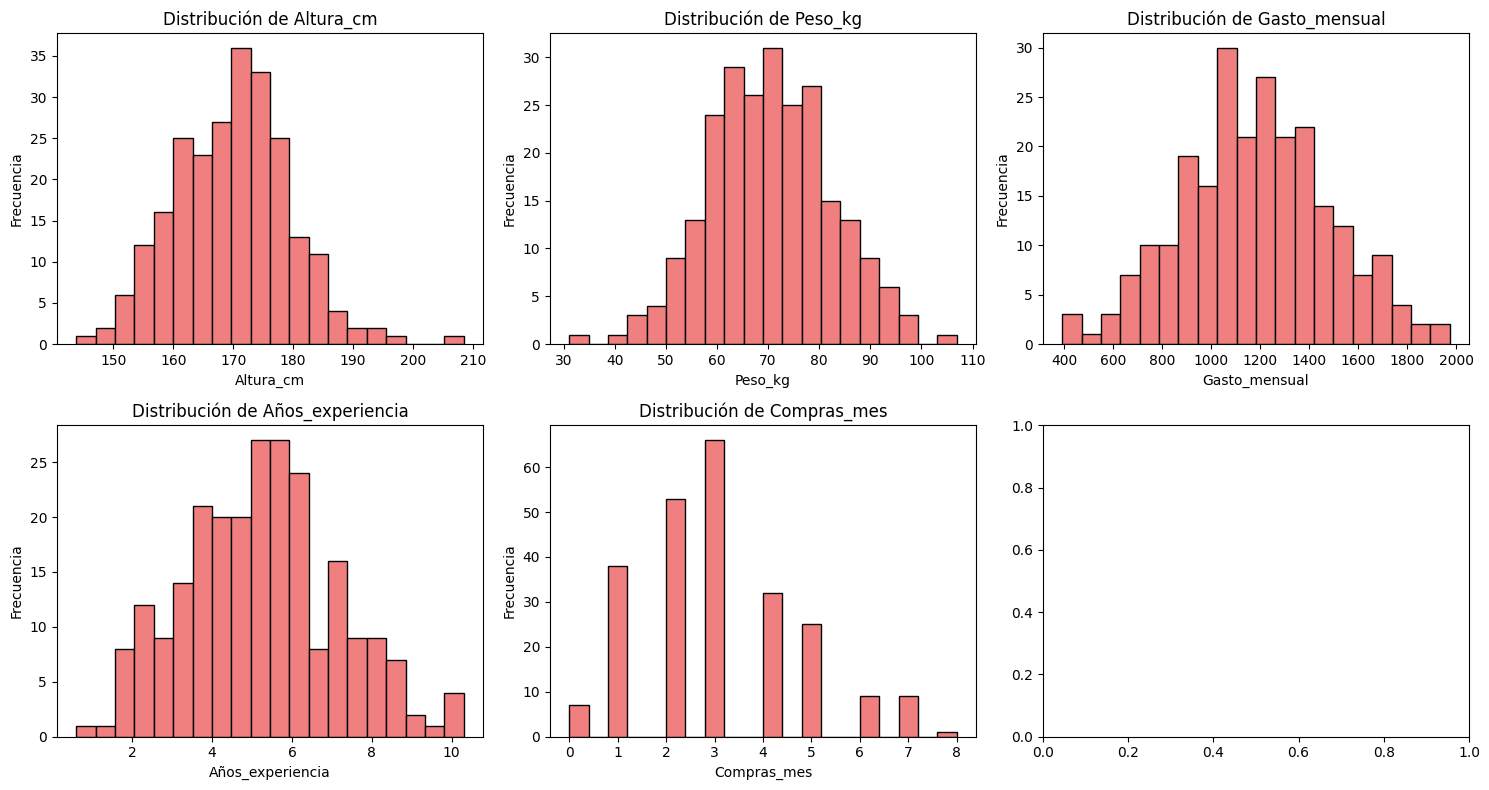

In [110]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(exclude="object").columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', color='lightcoral')
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


## Outliers

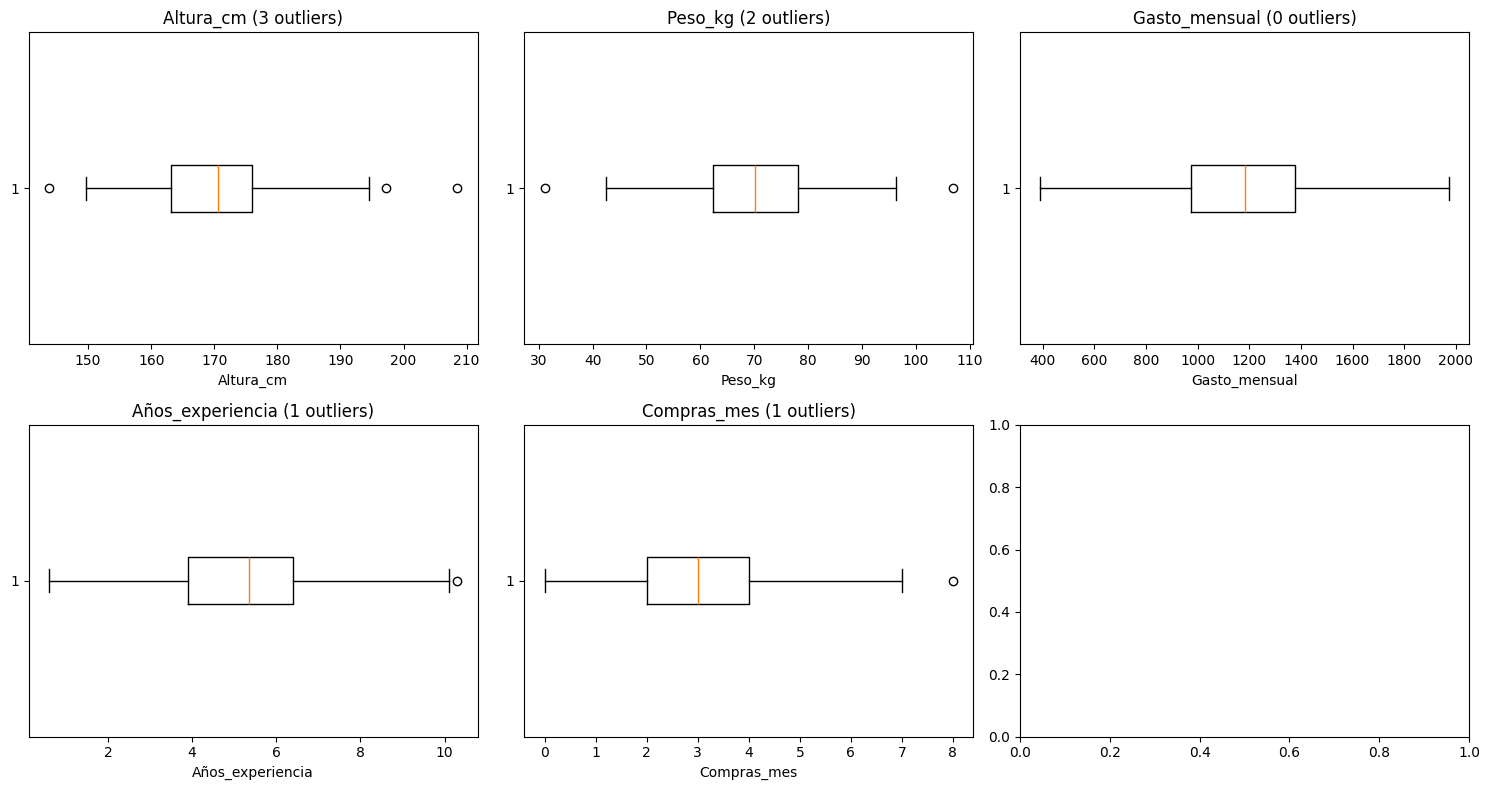

In [111]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(exclude="object").columns

# Calculamos outliers por IQR
outliers = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    outliers[col] = n_outliers

    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(f"{col} ({n_outliers} outliers)")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


In [112]:
for col, cantidad in outliers.items():
    print(f"{col}: {cantidad} valores atípicos")

Altura_cm: 3 valores atípicos
Peso_kg: 2 valores atípicos
Gasto_mensual: 0 valores atípicos
Años_experiencia: 1 valores atípicos
Compras_mes: 1 valores atípicos


In [113]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]

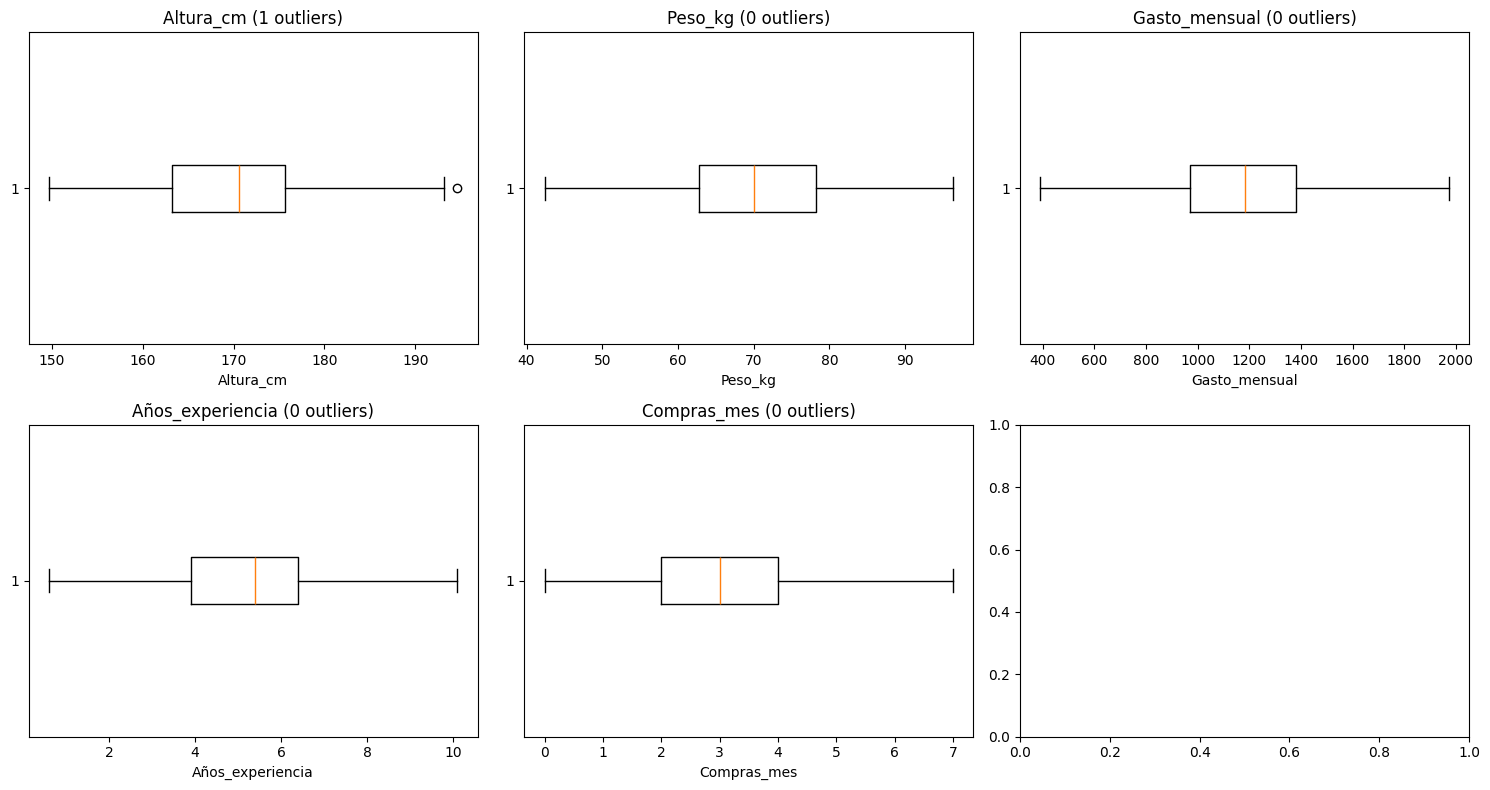

In [114]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(exclude="object").columns

# Calculamos outliers por IQR
outliers = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    outliers[col] = n_outliers

    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(f"{col} ({n_outliers} outliers)")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [115]:
Q1 = df["Altura_cm"].quantile(0.25)
Q3 = df["Altura_cm"].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df = df[(df["Altura_cm"] >= lim_inf) & (df["Altura_cm"] <= lim_sup)]

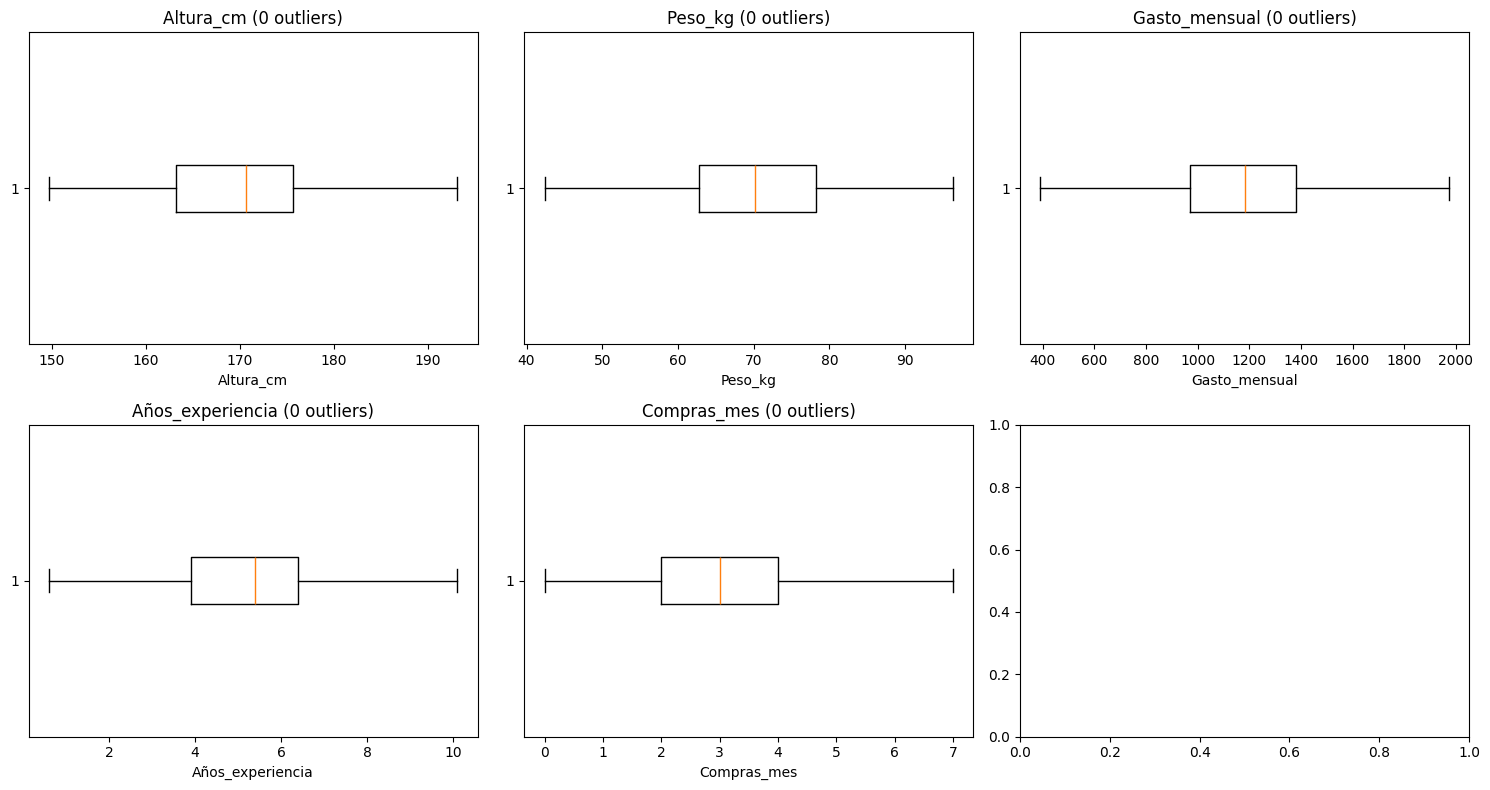

In [116]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(exclude="object").columns

# Calculamos outliers por IQR
outliers = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    outliers[col] = n_outliers

    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(f"{col} ({n_outliers} outliers)")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## División datos

In [117]:
from sklearn.model_selection import train_test_split

X = df.drop("Compras_mes", axis=1)  # variables explicatives
y = df["Compras_mes"]               # variable objectiu

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Separación columnas por tipo de datos

In [118]:
# Separación de columnas numéricas y categóricas
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

## Encoders

In [119]:
# Aplicamos LabelEncoder a las categóricas
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    encoders[col] = le

In [120]:
X_train.head()

,Altura_cm,Peso_kg,Gasto_mensual,Años_experiencia,Región,Nivel_estudios
58,173.3,79.8,1502.0,4.9,0,3
118,181.4,73.9,1067.0,7.0,0,3
143,171.8,63.7,1604.0,8.6,2,1
199,158.6,69.3,1581.0,5.4,2,1
67,180.0,62.9,1139.0,5.9,2,1


In [121]:
X_test.head()

,Altura_cm,Peso_kg,Gasto_mensual,Años_experiencia,Región,Nivel_estudios
226,170.6,77.4,816.0,1.9,0,3
68,173.6,76.6,1311.0,4.9,1,0
9,175.4,74.9,1464.0,3.4,3,2
174,172.8,74.0,1972.0,7.8,0,3
15,164.4,64.2,1362.0,5.9,2,1


## Correlaciones

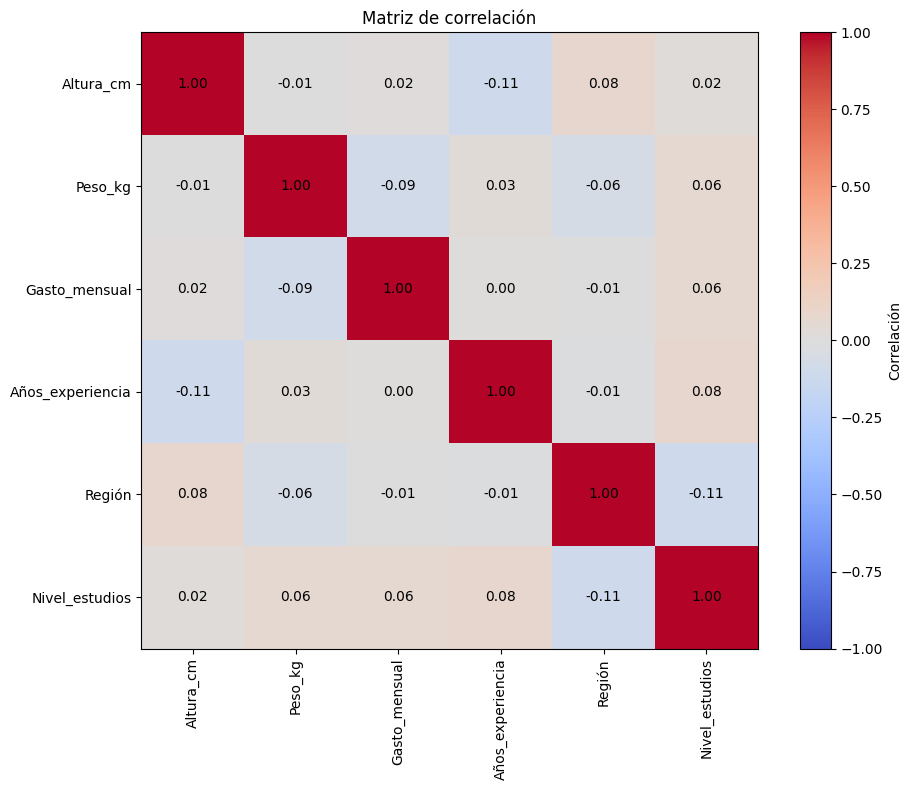

In [122]:
import matplotlib.pyplot as plt

correlation_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")

cols = X_train.columns
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        value = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=10)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Evaluación de la matriz de correlación

Todas las correlaciones están entre -0.11 y 0.08, lo que indica que **no hay relaciones lineales fuertes** entre las variables del dataset.

- No existe **multicolinealidad**, así que no hay redundancia entre variables.
- Ninguna variable parece tener una **influencia clara sobre otra**.
- Esto sugiere que puede haber **relaciones más complejas o no lineales** que la matriz de correlación no refleja.

## Normalización y escalado

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [124]:
X_train.head()

,Altura_cm,Peso_kg,Gasto_mensual,Años_experiencia,Región,Nivel_estudios
58,0.396738,0.846791,0.980026,-0.257071,0,3
118,1.285285,0.329395,-0.446176,0.825300,0,3
143,0.232192,-0.565087,1.314446,1.649963,2,1
199,-1.215810,-0.073999,1.239037,0.000636,2,1
67,1.131709,-0.635242,-0.210115,0.258344,2,1


In [125]:
X_test.head()

,Altura_cm,Peso_kg,Gasto_mensual,Años_experiencia,Región,Nivel_estudios
226,0.100556,0.636325,-1.269111,-1.803315,0,3
68,0.429647,0.566169,0.353808,-0.257071,1,0
9,0.627102,0.417089,0.855438,-1.030193,3,2
174,0.341889,0.338164,2.520980,1.237631,0,3
15,-0.579566,-0.521240,0.521018,0.258344,2,1


## PCA

In [126]:
from sklearn.decomposition import PCA

# Aplicamos PCA con 2 componentes
pca = PCA(n_components=2)

# Ajustamos solo con X_train
X_train_pca = pca.fit_transform(X_train)

# Transformamos X_test con el mismo ajuste
X_test_pca = pca.transform(X_test)

# Mostramos la varianza explicada por cada componente
print("Varianza explicada por la primera componente (PC1):", round(pca.explained_variance_ratio_[0], 2))
print("Varianza explicada por la segunda componente (PC2):", round(pca.explained_variance_ratio_[1], 2))
print("Varianza total explicada con 2 componentes:", round(sum(pca.explained_variance_ratio_), 2))

Varianza explicada por la primera componente (PC1): 0.22
Varianza explicada por la segunda componente (PC2): 0.18
Varianza total explicada con 2 componentes: 0.4


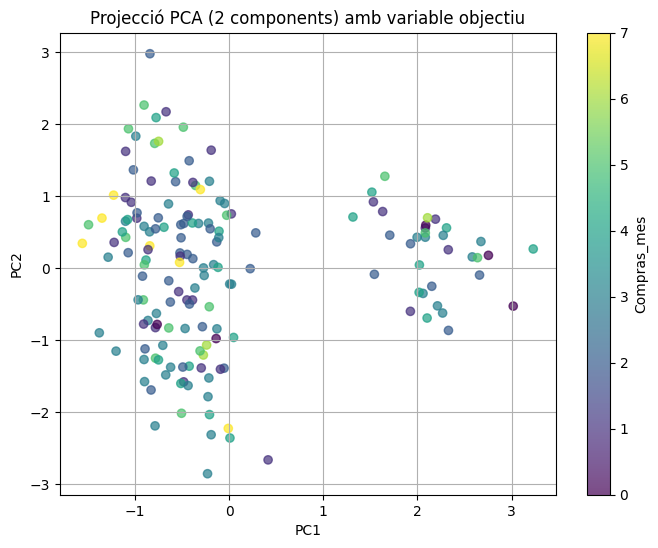

In [127]:
# Representació amb color segons el valor de 'Compras_mes'
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Compras_mes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projecció PCA (2 components) amb variable objectiu")
plt.grid(True)
plt.show()

El gráfico de PCA con 2 componentes no muestra una separación clara entre los valores de la variable objetivo Compras_mes. Los puntos aparecen mezclados, aunque en algunas zonas del gráfico (por ejemplo, valores positivos de PC1) se aprecia una ligera agrupación de valores más bajos. En general, no hay una estructura evidente que relacione las componentes principales con el objetivo, lo que sugiere que PCA puede no ser útil por sí sola para explicar la variable de salida, aunque sigue siendo válida para reducir la dimensionalidad antes de aplicar modelos complejos.

In [128]:
from sklearn.decomposition import PCA

# PCA con 3 componentes
pca3 = PCA(n_components=3)
pca3.fit(X_train)
print("Con 3 componentes:", round(sum(pca3.explained_variance_ratio_), 2))

# PCA con 4 componentes
pca4 = PCA(n_components=4)
pca4.fit(X_train)
print("Con 4 componentes:", round(sum(pca4.explained_variance_ratio_), 2))

# PCA con 5 componentes
pca5 = PCA(n_components=5)
pca5.fit(X_train)
print("Con 5 componentes:", round(sum(pca5.explained_variance_ratio_), 2))

# PCA con 6 componentes
pca6 = PCA(n_components=6)
pca6.fit(X_train)
print("Con 6 componentes:", round(sum(pca6.explained_variance_ratio_), 2))


Con 3 componentes: 0.56
Con 4 componentes: 0.73
Con 5 componentes: 0.87
Con 6 componentes: 1.0


# PIPELINES

In [129]:
df = pd.read_csv(ruta)

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# 1. Antes: limpiar y preparar dataframe
df = df.drop(columns=["ID_cliente"])
df = df.drop_duplicates()

df = df.dropna(subset=['Compras_mes'])

# 2. Separar variables y dividir
X = df.drop("Compras_mes", axis=1)
y = df["Compras_mes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Definir columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [131]:
# 4. Crear transformadores para cada tipo de columna
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 5. ColumnTransformer para aplicar a cada tipo
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [132]:
# 6. Pipeline final con preprocesamiento + modelo
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 7. Entrenar el pipeline
pipeline.fit(X_train, y_train)

# 8. Predecir
y_pred = pipeline.predict(X_test)